# ML Training — XGBoost & Random Forest
K-fold training with MLflow logging, feature importances, calibration and prediction heatmaps.
Uses the same H5 data pipeline as `hybrid_manager_V2.py`.

**Split strategy:** folds are computed on the *location* level (same as the CNN pipeline), so no
neighboring pixels from the same image appear in both train and val sets.

In [1]:
import os, sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import joblib
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.calibration import calibration_curve
import xgboost as xgb


def find_project_root(start=None):
    cur = Path(start or os.getcwd()).resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / 'NNsTorchV2').is_dir():
            return candidate
    raise RuntimeError('Could not find project root containing NNsTorchV2')


PROJECT_ROOT = find_project_root()
HYBRID_ROOT = PROJECT_ROOT / 'NNsTorchV2' / 'HybridTrainV2'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from NNsTorchV2.core.config_paths import set_load_path
from NNsTorchV2.core.data_discovery_V2 import discover_samples, discover_data_files_for_location
from NNsTorchV2.core.data_loading_V2 import load_and_aggregate_location

print('Imports OK')


Imports OK


In [10]:
# ── Config ───────────────────────────────────────────────────────────────────
SYSTEM        = 'GPU'
POWER_MODE    = '4kw_both'
SUBFOLDER     = 'Taris/Data_ML_V1_h5'
MASK_TYPE     = 'alternative'
INVERT_MASK   = False
DATA_REGIME   = 'postprocessed'
PPT_PHASES    = 'all'
PPT_AMPS      = 6
DIRS          = [1,  5,  6]
N_SPLITS      = 3
MAX_LOCATIONS = None   # set int to limit for quick tests
MIN_MASK_AREA = 0

MLFLOW_URI        = os.environ.get('MLFLOW_TRACKING_URI', 'sqlite:////tmp/mlflow_experiments/mlflow.db')
MLFLOW_EXPERIMENT = 'MLTraining'

# How many val locations to show in prediction heatmaps
N_VIZ_SAMPLES = 4

# ── Fold splits source ────────────────────────────────────────────────────────
# Set to a timestamp folder to reuse existing UNet splits (same train/val for XGB + RF).
# Set to None to generate fresh splits with StratifiedKFold.
#FOLD_SPLITS_DIR = os.path.join(HYBRID_ROOT, 'fold_splits', 'unet', '20260413-095040')
FOLD_SPLITS_DIR = os.path.join(HYBRID_ROOT, 'fold_splits', 'mlp_cnn', '20260413-172702')
LOAD_PATH = os.path.join(set_load_path(SYSTEM), SUBFOLDER)
print(f'Load path:       {LOAD_PATH}')
print(f'MLflow URI:      {MLFLOW_URI}')
print(f'Fold splits dir: {FOLD_SPLITS_DIR}  (exists={os.path.isdir(FOLD_SPLITS_DIR) if FOLD_SPLITS_DIR else "N/A"})')

Load path:       /home/aaverin/RZ-Dienste/hpc-user/aaverin/2025/2025-11-04-Av-ZIKA-Mirko-Taris-Hologen-2kw-measurements/Taris/Data_ML_V1_h5
MLflow URI:      sqlite:////tmp/mlflow_experiments/mlflow.db
Fold splits dir: /home/aaverin/RZ-Dienste/hpc-user/aaverin/Python/KIprojV2_Claude/NNsTorchV2/HybridTrainV2/fold_splits/mlp_cnn/20260413-172702  (exists=True)


In [3]:
# ── Feature names ─────────────────────────────────────────────────────────────
# Order mirrors data_loading_V2.py: sorted PCA → sorted PPT (phase then amp) → sorted ICA
# PCA: a=10_width=110 < a=10_width=280  (sort by (a, width))
# PPT: a=0_width=110  < a=0_width=280   (sort by (a, width))
# ICA: a=0_width=280
FEATURE_NAMES = (
    [f'pct_s{i}'   for i in range(6)]   +  # PCA  width=110 (6)
    [f'pct_l{i}'   for i in range(6)]   +  # PCA  width=280 (6)
    [f'phase_s{i}' for i in range(26)]  +  # PPT  width=110 Phase (26)
    [f'amp_s{i}'   for i in range(6)]   +  # PPT  width=110 Amp   (6)
    [f'phase_l{i}' for i in range(26)]  +  # PPT  width=280 Phase (26)
    [f'amp_l{i}'   for i in range(6)]   +  # PPT  width=280 Amp   (6)
    [f'ica{i}'     for i in range(6)]      # ICA  width=280       (6)
)
assert len(FEATURE_NAMES) == 82, f'Expected 82 features, got {len(FEATURE_NAMES)}'
print(f'Feature names: {len(FEATURE_NAMES)} features defined')

Feature names: 82 features defined


In [4]:
# ── Model definitions ─────────────────────────────────────────────────────────
XGB_PARAMS = dict(
    objective        = 'binary:logistic',
    max_depth        = 4,
    min_child_weight = 150,
    gamma            = 5,
    learning_rate    = 0.02,
    n_estimators     = 800,
    scale_pos_weight = 2,
    colsample_bytree = 0.6,
    subsample        = 0.6,
    reg_alpha        = 1.0,
    reg_lambda       = 5.0,
    tree_method      = 'hist',
    eval_metric      = ['logloss'],
    n_jobs           = -1,
    random_state     = 42,
)
XGB_EARLY_STOPPING_ROUNDS = 100

# RF_PARAMS = dict(
#     n_estimators     = 300,
#     max_depth        = 8,
#     min_samples_leaf = 100,
#     max_features     = 'sqrt',
#     class_weight     = 'balanced',
#     n_jobs           = -1,
#     random_state     = 42,
# )
RF_PARAMS = dict(
    n_estimators     = 150,
    max_depth        = 10,
    min_samples_leaf = 50,
    max_features     = "sqrt",
    max_samples      = 0.4, 
    class_weight     = {0: 1, 1: 2},
    n_jobs           = -1,
    random_state     = 42,
)

MODELS = {
    'xgb': xgb.XGBClassifier(**XGB_PARAMS),
    'rf':  RandomForestClassifier(**RF_PARAMS),
}
print('Model configs ready')

Model configs ready


In [5]:
# ── Helpers ───────────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve as sklearn_roc_curve

def seg_metrics(y_true, y_pred, y_prob):
    """Compute prec, rec, f1, iou, auc, logloss."""
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    prec = tp / (tp + fp + 1e-7)
    rec  = tp / (tp + fn + 1e-7)
    f1   = 2 * prec * rec / (prec + rec + 1e-7)
    iou  = tp / (tp + fp + fn + 1e-7)
    auc  = roc_auc_score(y_true, y_prob) if y_true.sum() > 0 else 0.0
    ll   = log_loss(y_true, y_prob)
    return dict(prec=prec, rec=rec, f1=f1, iou=iou, auc=auc, logloss=ll)


def plot_feature_importance(model, model_name, top_n=20, feature_names=None):
    """Bar chart of top-N feature importances with named x-axis if provided."""
    imp = model.feature_importances_
    idx = np.argsort(imp)[-top_n:][::-1]
    labels = ([feature_names[i] for i in idx] if feature_names is not None
              else idx.tolist())
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(len(idx)), imp[idx])
    ax.set_xticks(range(len(idx)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Importance')
    ax.set_title(f'{model_name} — Top {top_n} Feature Importances')
    fig.tight_layout()
    return fig


def plot_calibration(y_true, y_prob, model_name):
    """Calibration curve. Returns matplotlib figure."""
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(prob_pred, prob_true, marker='o', label=model_name)
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'Calibration Curve — {model_name}')
    ax.legend()
    fig.tight_layout()
    return fig


def plot_roc_with_ci(fold_roc_data, model_name):
    """ROC curves for all folds + mean ± std band.

    fold_roc_data: list of (fpr, tpr, auc_val) per fold.
    """
    base_fpr = np.linspace(0, 1, 200)
    tprs, aucs = [], []
    fig, ax = plt.subplots(figsize=(6, 5))
    for fold_i, (fpr, tpr, auc_val) in enumerate(fold_roc_data):
        ax.plot(fpr, tpr, color='grey', alpha=0.35, lw=1,
                label=f'Fold {fold_i+1} (AUC={auc_val:.3f})')
        tprs.append(np.interp(base_fpr, fpr, tpr))
        aucs.append(auc_val)
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr  = np.std(tprs,  axis=0)
    ax.plot(base_fpr, mean_tpr, 'b-', lw=2,
            label=f'Mean AUC={np.mean(aucs):.3f} ± {np.std(aucs):.3f}')
    ax.fill_between(base_fpr,
                    np.clip(mean_tpr - std_tpr, 0, 1),
                    np.clip(mean_tpr + std_tpr, 0, 1),
                    alpha=0.2, color='blue', label='±1 std')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC — {model_name}')
    ax.legend(fontsize=7)
    fig.tight_layout()
    return fig


def print_per_sample_iou(model, val_samples):
    """Print per-location IoU for the best val fold. Returns dict of {label: iou}."""
    results = {}
    for sample_name, loc_name in val_samples:
        fi = discover_data_files_for_location(
            LOAD_PATH, POWER_MODE, sample_name, loc_name, MASK_TYPE, DATA_REGIME)
        if fi is None:
            print(f'  [skip] {sample_name}/{loc_name}')
            continue
        data, mask = load_and_aggregate_location(
            fi, ppt_phases=PPT_PHASES, ppt_amps=PPT_AMPS,
            invert_mask=INVERT_MASK, data_regime=DATA_REGIME,
            min_mask_area=MIN_MASK_AREA)
        H, W, C = data.shape
        X_loc    = data.reshape(-1, C).astype(np.float32)
        pred_bin = model.predict(X_loc).reshape(H, W)
        mask_flat = mask.reshape(-1)
        pred_flat = pred_bin.reshape(-1)
        tp  = int(((mask_flat == 1) & (pred_flat == 1)).sum())
        fp  = int(((mask_flat == 0) & (pred_flat == 1)).sum())
        fn  = int(((mask_flat == 1) & (pred_flat == 0)).sum())
        iou = tp / (tp + fp + fn + 1e-7)
        label = f'{sample_name}/{loc_name}'
        results[label] = iou
        print(f'  {label:40s}  IoU={iou:.4f}')
    return results


def plot_predictions(model, val_samples, n_samples=4):
    """Grid: [Input Ch0 | GT Mask | Pred Binary | Probability] for val locations."""
    viz = val_samples[:n_samples]
    fig, axes = plt.subplots(len(viz), 4, figsize=(18, 4.5 * len(viz)))
    if len(viz) == 1:
        axes = axes[np.newaxis]
    for row, (sample_name, loc_name) in enumerate(viz):
        fi = discover_data_files_for_location(
            LOAD_PATH, POWER_MODE, sample_name, loc_name, MASK_TYPE, DATA_REGIME)
        if fi is None:
            print(f'[skip] {sample_name}/{loc_name}: not found')
            continue
        data, mask = load_and_aggregate_location(
            fi, ppt_phases=PPT_PHASES, ppt_amps=PPT_AMPS,
            invert_mask=INVERT_MASK, data_regime=DATA_REGIME,
            min_mask_area=MIN_MASK_AREA)
        H, W, C = data.shape
        X_loc     = data.reshape(-1, C).astype(np.float32)
        pred_bin  = model.predict(X_loc).reshape(H, W)
        pred_prob = model.predict_proba(X_loc)[:, 1].reshape(H, W)

        tp  = int(((mask == 1) & (pred_bin == 1)).sum())
        fp  = int(((mask == 0) & (pred_bin == 1)).sum())
        fn  = int(((mask == 1) & (pred_bin == 0)).sum())
        iou = tp / (tp + fp + fn + 1e-7)
        f1  = 2 * tp / (2 * tp + fp + fn + 1e-7)

        ax = axes[row]
        ax[0].imshow(data[:, :, 0], cmap='viridis')
        ax[0].set_title(f'{sample_name}/{loc_name}\nInput Ch0'); ax[0].axis('off')
        ax[1].imshow(mask,     cmap='gray', vmin=0, vmax=1)
        ax[1].set_title('GT Mask'); ax[1].axis('off')
        ax[2].imshow(pred_bin, cmap='gray', vmin=0, vmax=1)
        ax[2].set_title(f'Pred  F1={f1:.3f}  IoU={iou:.3f}'); ax[2].axis('off')
        im = ax[3].imshow(pred_prob, cmap='hot', vmin=0, vmax=1)
        ax[3].set_title('Probability'); ax[3].axis('off')
        plt.colorbar(im, ax=ax[3], fraction=0.046)
    fig.tight_layout()
    return fig


print('Helpers defined')

Helpers defined


In [11]:
# ── Discover samples & load per-location pixel chunks ─────────────────────────
#
# We keep each location as a separate (X_i, y_i) chunk so that k-fold splits
# happen at the location level — no neighboring pixels from the same image
# can appear in both train and val sets.

def _strat_class(pos_ratio: float) -> int:
    """Bucket positive-pixel ratio into 3 classes for stratified splitting."""
    return 0 if pos_ratio < 0.1 else (1 if pos_ratio < 0.15 else 2)


all_samples = discover_samples(
    LOAD_PATH, POWER_MODE, dirs=DIRS,
    mask_type=MASK_TYPE, data_regime=DATA_REGIME,
    max_locations=MAX_LOCATIONS)
print(f'Found {len(all_samples)} locations')

samples_data    = []   # list of (X_i: (N_i, C), y_i: (N_i,)) per location
sample_classes  = []   # stratification label per location
valid_samples   = []   # parallel list to all_samples (skipped removed)

for i, (sample_name, loc_name) in enumerate(all_samples):
    fi = discover_data_files_for_location(
        LOAD_PATH, POWER_MODE, sample_name, loc_name, MASK_TYPE, DATA_REGIME)
    if fi is None:
        print(f'  [skip] {sample_name}/{loc_name}')
        continue
    data, mask = load_and_aggregate_location(
        fi, ppt_phases=PPT_PHASES, ppt_amps=PPT_AMPS,
        invert_mask=INVERT_MASK, data_regime=DATA_REGIME,
        min_mask_area=MIN_MASK_AREA)
    H, W, C = data.shape
    X_i = data.reshape(-1, C).astype(np.float32)
    y_i = mask.reshape(-1).astype(np.int32)
    samples_data.append((X_i, y_i))
    sample_classes.append(_strat_class(float(y_i.mean())))
    valid_samples.append((sample_name, loc_name))
    if (i + 1) % 10 == 0:
        print(f'  Loaded {i+1}/{len(all_samples)}')

sample_classes = np.array(sample_classes)
n_features = samples_data[0][0].shape[1]
total_px   = sum(len(y) for _, y in samples_data)
pos_ratio  = sum((y == 1).sum() for _, y in samples_data) / total_px

print(f'\nLocations loaded : {len(samples_data)}')
print(f'Total pixels     : {total_px:,}')
print(f'Features per px  : {n_features}')
print(f'Overall pos ratio: {pos_ratio:.4f}')
print(f'Strat classes    : {dict(zip(*np.unique(sample_classes, return_counts=True)))}')

Found 27 locations
  Loaded 10/27
  Loaded 20/27

Locations loaded : 27
Total pixels     : 6,857,800
Features per px  : 82
Overall pos ratio: 0.0918
Strat classes    : {np.int64(0): np.int64(20), np.int64(1): np.int64(7)}


In [12]:
# ── Training function ─────────────────────────────────────────────────────────
def _build_fold_splits(valid_samples, n_splits, sample_classes):
    """Return list of (tr_loc_idx, va_loc_idx) arrays — one per fold.

    If FOLD_SPLITS_DIR is set, loads from saved NPZ files (same splits as UNet).
    Falls back to StratifiedKFold when FOLD_SPLITS_DIR is None.
    """
    if FOLD_SPLITS_DIR is not None:
        npz_files = sorted(
            f for f in os.listdir(FOLD_SPLITS_DIR) if f.startswith('fold_') and f.endswith('.npz'))
        if not npz_files:
            raise FileNotFoundError(f'No fold_*.npz files in {FOLD_SPLITS_DIR}')
        name_to_idx = {s: i for i, s in enumerate(valid_samples)}
        splits = []
        for fname in npz_files:
            d = np.load(os.path.join(FOLD_SPLITS_DIR, fname), allow_pickle=True)
            tr_names = [tuple(x) for x in d['train_samples']]
            va_names = [tuple(x) for x in d['val_samples']]
            tr_loc = np.array([name_to_idx[s] for s in tr_names if s in name_to_idx])
            va_loc = np.array([name_to_idx[s] for s in va_names if s in name_to_idx])
            splits.append((tr_loc, va_loc))
        print(f'  Loaded {len(splits)} fold splits from {FOLD_SPLITS_DIR}')
        return splits
    else:
        kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        loc_idx = np.arange(len(valid_samples))
        print(f'  Generated {n_splits} fold splits with StratifiedKFold')
        return list(kf.split(loc_idx, sample_classes))
from datetime import datetime
ts = datetime.now().strftime('%Y%m%d-%H%M%S')

def train_model(model_name, model, samples_data, sample_classes, valid_samples,
                n_splits=N_SPLITS):
    """
    K-fold training split at the *location* level.
    Returns the model trained on the last fold.
    """
    mlflow.set_tracking_uri(MLFLOW_URI)
    mlflow.set_experiment(MLFLOW_EXPERIMENT)

    fold_splits   = _build_fold_splits(valid_samples, n_splits, sample_classes)
    fold_results  = []
    fold_roc_data = []   # (fpr, tpr, auc) per fold
    best_fold_iou  = -1.0
    best_fold_info = {}

    mlflow.start_run(run_name=model_name)
    try:
        run = mlflow.active_run()
        mlflow.log_params({
            **{k: str(v) for k, v in model.get_params().items()},
            'n_splits':       len(fold_splits),
            'n_locations':    len(samples_data),
            'total_pixels':   sum(len(y) for _, y in samples_data),
            'pos_ratio':      float(pos_ratio),
            'n_features':     n_features,
            'split_level':    'location',
            'data_regime':    DATA_REGIME,
            'mask_type':      MASK_TYPE,
            "samples":        DIRS,
            'invert_mask':    INVERT_MASK,
            'ppt_phases':     str(PPT_PHASES),
            'ppt_amps':       PPT_AMPS,
            'fold_splits_dir': str(FOLD_SPLITS_DIR),
        })

        for fold, (tr_loc, va_loc) in enumerate(fold_splits):
            X_tr = np.concatenate([samples_data[i][0] for i in tr_loc])
            y_tr = np.concatenate([samples_data[i][1] for i in tr_loc])
            X_va = np.concatenate([samples_data[i][0] for i in va_loc])
            y_va = np.concatenate([samples_data[i][1] for i in va_loc])

            val_sample_names = [valid_samples[i] for i in va_loc]
            print(f'  Fold {fold+1}: train {len(tr_loc)} locs ({len(X_tr):,} px)'
                  f' | val {len(va_loc)} locs ({len(X_va):,} px)')

            if model_name == 'xgb':
                try:
                    model.fit(X_tr, y_tr,
                              eval_set=[(X_tr, y_tr), (X_va, y_va)],
                              verbose=False,
                              early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS)
                except TypeError:
                    model.set_params(early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS)
                    model.fit(X_tr, y_tr,
                              eval_set=[(X_tr, y_tr), (X_va, y_va)],
                              verbose=False)
                evals  = model.evals_result()
                tr_e   = evals['validation_0']
                va_e   = evals['validation_1']
                score_key = 'aucpr' if 'aucpr' in va_e else ('auc' if 'auc' in va_e else None)
                n_iter = len(tr_e['logloss'])
                offset = fold * n_iter
                for s, (tll, vll) in enumerate(zip(tr_e['logloss'], va_e['logloss'])):
                    metrics = {
                        f'fold{fold+1}/iter_tr_logloss': tll,
                        f'fold{fold+1}/iter_va_logloss': vll,
                    }
                    if score_key is not None:
                        metrics[f'fold{fold+1}/iter_tr_{score_key}'] = tr_e[score_key][s]
                        metrics[f'fold{fold+1}/iter_va_{score_key}'] = va_e[score_key][s]
                    mlflow.log_metrics(metrics, step=offset + s)
                if hasattr(model, 'best_iteration') and model.best_iteration is not None:
                    mlflow.log_metric(f'fold{fold+1}/best_iteration', model.best_iteration, step=fold)
                    print(f'         best_iteration={model.best_iteration}')
            else:
                model.fit(X_tr, y_tr)

            prob_tr = model.predict_proba(X_tr)[:, 1]
            prob_va = model.predict_proba(X_va)[:, 1]
            m_tr = seg_metrics(y_tr, model.predict(X_tr), prob_tr)
            m_va = seg_metrics(y_va, model.predict(X_va), prob_va)
            fold_results.append(m_va)

            fpr, tpr, _ = sklearn_roc_curve(y_va, prob_va)
            fold_roc_data.append((fpr, tpr, m_va['auc']))

            mlflow.log_metrics({f'fold{fold+1}/tr_{k}': v for k, v in m_tr.items()}, step=fold)
            mlflow.log_metrics({f'fold{fold+1}/va_{k}': v for k, v in m_va.items()}, step=fold)
            print(f'         AUC={m_va["auc"]:.4f}  F1={m_va["f1"]:.4f}'
                  f'  IoU={m_va["iou"]:.4f}  prec={m_va["prec"]:.4f}  rec={m_va["rec"]:.4f}')

            if m_va['iou'] > best_fold_iou:
                best_fold_iou  = m_va['iou']
                best_fold_info = {'y_va': y_va, 'prob_va': prob_va,
                                  'val_samples': val_sample_names,
                                  'fold': fold + 1}
            
            model_dir = f'ML_models/{ts}'
            os.makedirs(model_dir, exist_ok=True)
            model_path = os.path.join(model_dir, f'{model_name}_{fold}_trained.joblib')
            joblib.dump(model, model_path)

        # ── Summary metrics ──────────────────────────────────────────────────
        print(f'\n  Summary ({len(fold_splits)}-fold):')
        for k in fold_results[0]:
            vals = [r[k] for r in fold_results]
            mlflow.log_metrics({
                f'mean_{k}': float(np.mean(vals)),
                f'std_{k}':  float(np.std(vals)),
            }, step=len(fold_splits))
            print(f'    {k}: {np.mean(vals):.4f} ± {np.std(vals):.4f}')

        # ── Feature importances ──────────────────────────────────────────────
        fig_imp = plot_feature_importance(model, model_name, feature_names=FEATURE_NAMES)
        plt.show()
        mlflow.log_figure(fig_imp, 'plots/feature_importance.png')
        plt.close(fig_imp)

        # ── ROC curve with fold confidence band ──────────────────────────────
        fig_roc = plot_roc_with_ci(fold_roc_data, model_name)
        plt.show()
        mlflow.log_figure(fig_roc, 'plots/roc_curve.png')
        plt.close(fig_roc)

        # ── Calibration curve (best fold val pixels) ─────────────────────────
        fig_cal = plot_calibration(best_fold_info['y_va'], best_fold_info['prob_va'], model_name)
        plt.show()
        mlflow.log_figure(fig_cal, 'plots/calibration_curve.png')
        plt.close(fig_cal)

        pt, pp = calibration_curve(best_fold_info['y_va'], best_fold_info['prob_va'], n_bins=10)
        for i, (x, yb) in enumerate(zip(pp, pt)):
            mlflow.log_metrics({'calib_prob_pred': float(x), 'calib_prob_true': float(yb)}, step=i)

        # ── Per-sample IoU (best fold) ────────────────────────────────────────
        print(f'\n  Per-sample IoU — best fold {best_fold_info["fold"]} '
              f'(val IoU={best_fold_iou:.4f}):')
        sample_ious = print_per_sample_iou(model, best_fold_info['val_samples'])
        for i, (label, iou_val) in enumerate(sample_ious.items()):
            mlflow.log_metrics({f'best_fold/sample_{i}_iou': iou_val}, step=i)

        # ── Prediction heatmaps (best fold val locations only) ───────────────
        fig_pred = plot_predictions(model, best_fold_info['val_samples'],
                                    n_samples=N_VIZ_SAMPLES)
        plt.show()
        mlflow.log_figure(fig_pred, 'plots/prediction_heatmaps.png')
        plt.close(fig_pred)

        # ── Save model artifact ──────────────────────────────────────────────
        model_dir = f'ML_models/{ts}'
        os.makedirs(model_dir, exist_ok=True)
        model_path = os.path.join(model_dir, f'{model_name}_trained.joblib')
        joblib.dump(model, model_path)
        mlflow.log_artifact(model_path)

        print(f'\nMLflow run: {run.info.run_id}')

    finally:
        mlflow.end_run()

    return model


print('train_model() defined')

train_model() defined


=== XGBoost ===
  Loaded 3 fold splits from /home/aaverin/RZ-Dienste/hpc-user/aaverin/Python/KIprojV2_Claude/NNsTorchV2/HybridTrainV2/fold_splits/mlp_cnn/20260413-172702


  Fold 1: train 18 locs (4,593,400 px) | val 9 locs (2,264,400 px)
         best_iteration=210
         AUC=0.9234  F1=0.5879  IoU=0.4163  prec=0.5435  rec=0.6401
  Fold 2: train 18 locs (4,551,400 px) | val 9 locs (2,306,400 px)
         best_iteration=639
         AUC=0.9462  F1=0.6497  IoU=0.4812  prec=0.6183  rec=0.6845
  Fold 3: train 18 locs (4,570,800 px) | val 9 locs (2,287,000 px)
         best_iteration=689
         AUC=0.9586  F1=0.6763  IoU=0.5109  prec=0.7413  rec=0.6218

  Summary (3-fold):
    prec: 0.6344 ± 0.0815
    rec: 0.6488 ± 0.0263
    f1: 0.6380 ± 0.0370
    iou: 0.4695 ± 0.0395
    auc: 0.9427 ± 0.0146
    logloss: 0.1668 ± 0.0214


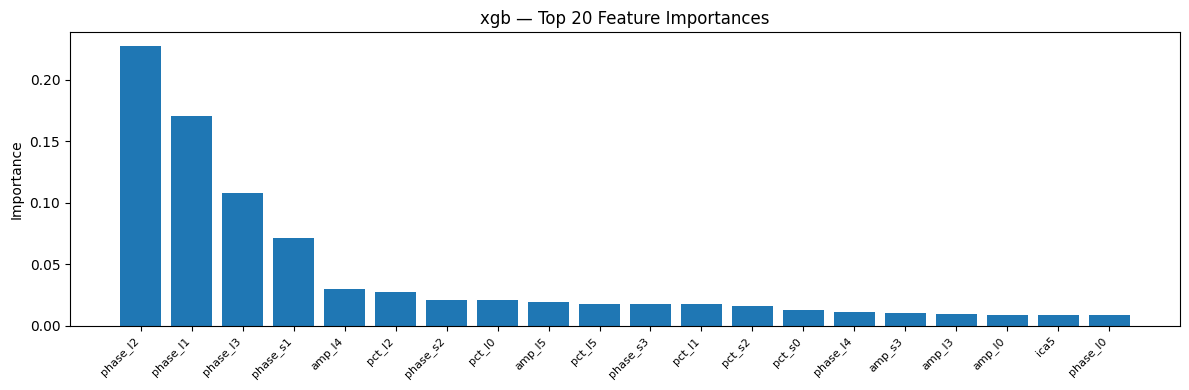

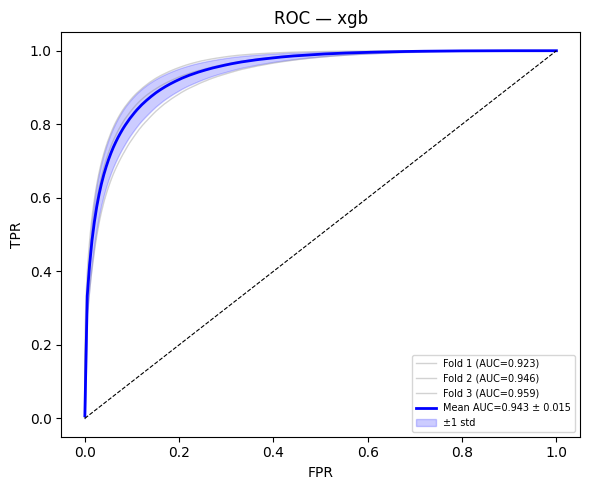

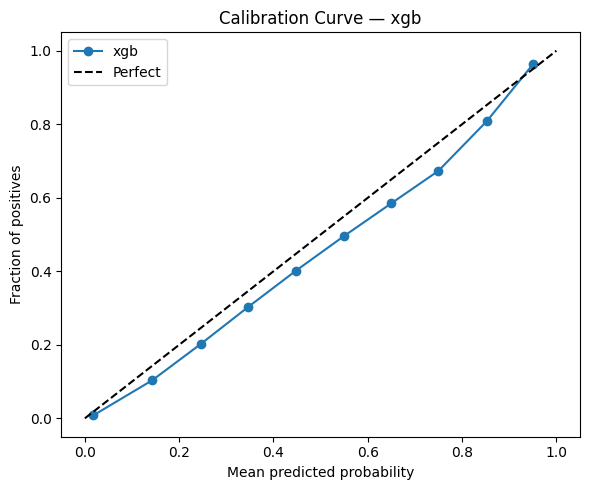


  Per-sample IoU — best fold 3 (val IoU=0.5109):
  s1/bottom_mid                             IoU=0.4305
  s1/bottom_right                           IoU=0.3806
  s1/top_right                              IoU=0.2972
  s5/bottom_left                            IoU=0.5270
  s5/bottom_right                           IoU=0.5728
  s5/mid_left                               IoU=0.3746
  s5/top_mid                                IoU=0.6562
  s6/bottom_mid                             IoU=0.6706
  s6/top_left                               IoU=0.6105


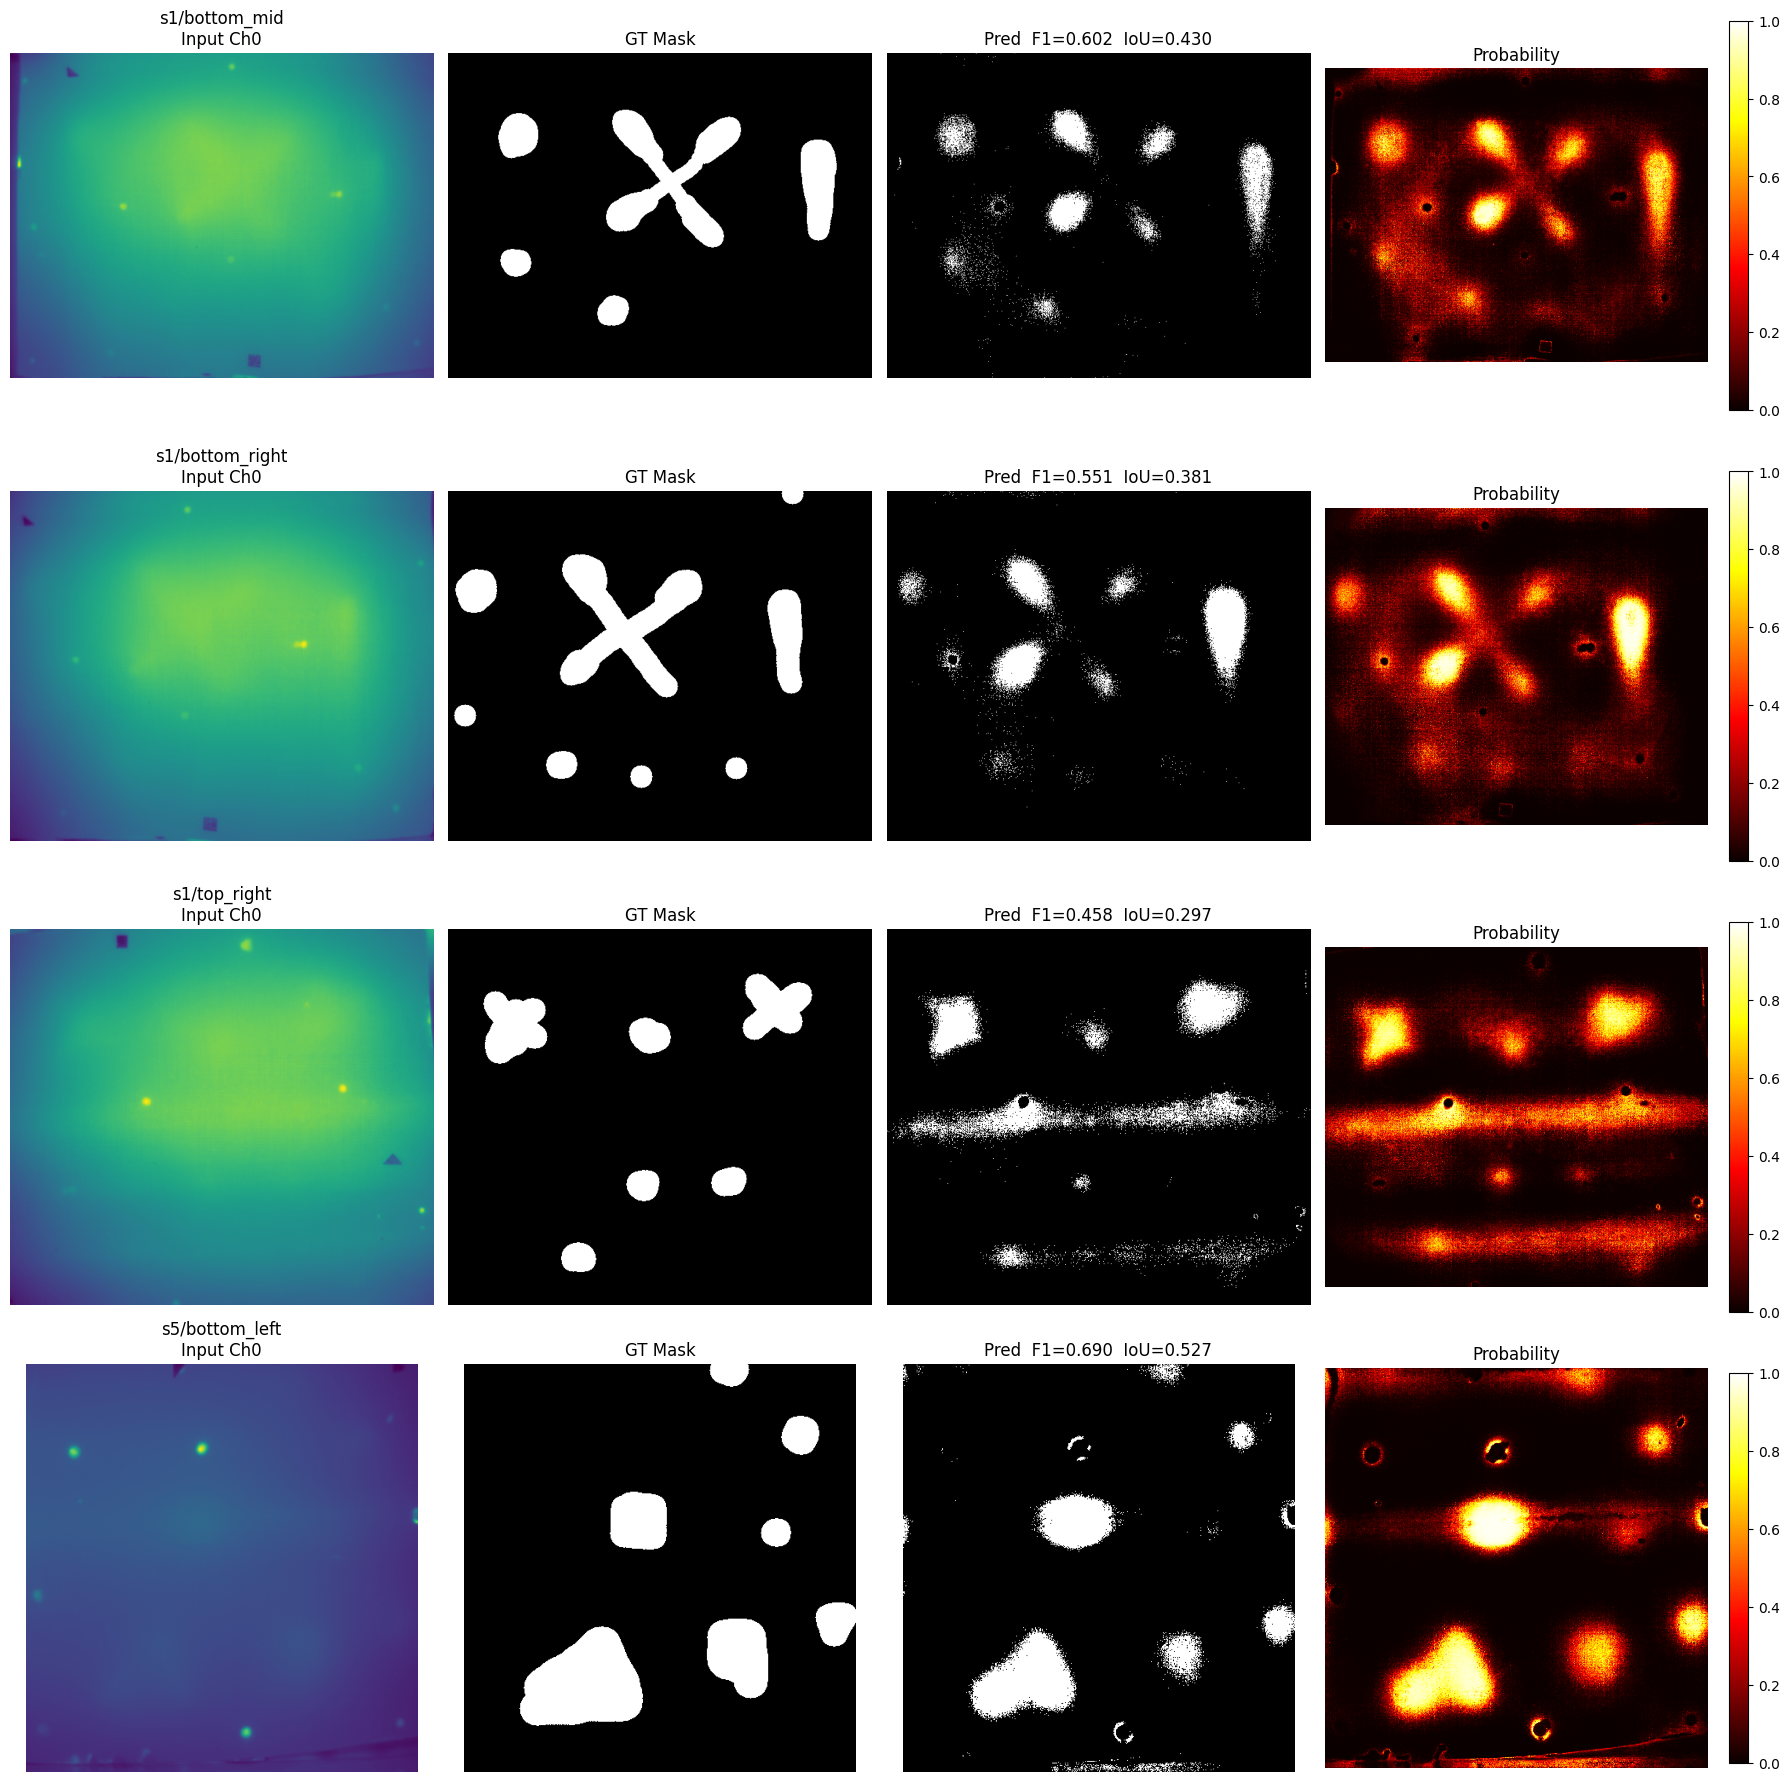


MLflow run: 68c410843b7d4ddcbbdee14f4d8a8338


In [13]:
# ── Train XGBoost ─────────────────────────────────────────────────────────────
print('=== XGBoost ===')
xgb_model = train_model('xgb', MODELS['xgb'], samples_data, sample_classes, valid_samples)

  Loaded 3 fold splits from /home/aaverin/RZ-Dienste/hpc-user/aaverin/Python/KIprojV2_Claude/NNsTorchV2/HybridTrainV2/fold_splits/unet/20260413-095040
Best threshold on last validation fold: 0.41
  train IoU=0.4472 F1=0.6180 prec=0.6068 rec=0.6297
  val   IoU=0.3300 F1=0.4962 prec=0.4447 rec=0.5614


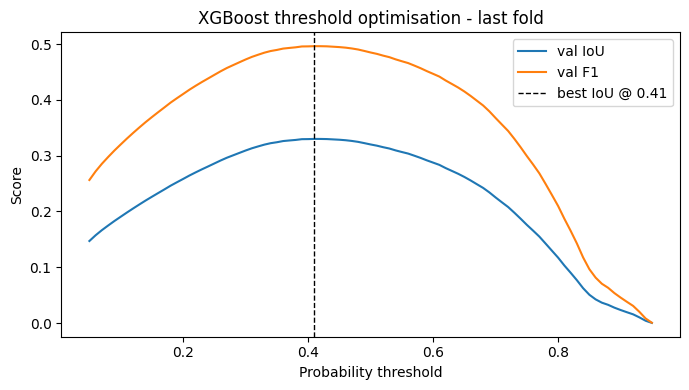

In [12]:
# ── XGBoost threshold optimisation (returned model / last fold) ──────────────
def _binary_metrics_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(np.int32)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    prec = tp / (tp + fp + 1e-7)
    rec = tp / (tp + fn + 1e-7)
    f1 = 2 * prec * rec / (prec + rec + 1e-7)
    iou = tp / (tp + fp + fn + 1e-7)
    return dict(threshold=float(threshold), prec=prec, rec=rec, f1=f1, iou=iou)

fold_splits = _build_fold_splits(valid_samples, N_SPLITS, sample_classes)
last_tr_loc, last_va_loc = fold_splits[-1]
X_tr_last = np.concatenate([samples_data[i][0] for i in last_tr_loc])
y_tr_last = np.concatenate([samples_data[i][1] for i in last_tr_loc])
X_va_last = np.concatenate([samples_data[i][0] for i in last_va_loc])
y_va_last = np.concatenate([samples_data[i][1] for i in last_va_loc])

prob_tr_last = xgb_model.predict_proba(X_tr_last)[:, 1]
prob_va_last = xgb_model.predict_proba(X_va_last)[:, 1]
thresholds = np.linspace(0.05, 0.95, 91)
va_scores = [_binary_metrics_at_threshold(y_va_last, prob_va_last, t) for t in thresholds]
best = max(va_scores, key=lambda m: m['iou'])
train_at_best = _binary_metrics_at_threshold(y_tr_last, prob_tr_last, best['threshold'])

print(f"Best threshold on last validation fold: {best['threshold']:.2f}")
print(f"  train IoU={train_at_best['iou']:.4f} F1={train_at_best['f1']:.4f} "
      f"prec={train_at_best['prec']:.4f} rec={train_at_best['rec']:.4f}")
print(f"  val   IoU={best['iou']:.4f} F1={best['f1']:.4f} "
      f"prec={best['prec']:.4f} rec={best['rec']:.4f}")

plt.figure(figsize=(7, 4))
plt.plot([m['threshold'] for m in va_scores], [m['iou'] for m in va_scores], label='val IoU')
plt.plot([m['threshold'] for m in va_scores], [m['f1'] for m in va_scores], label='val F1')
plt.axvline(best['threshold'], color='k', linestyle='--', linewidth=1, label=f"best IoU @ {best['threshold']:.2f}")
plt.xlabel('Probability threshold')
plt.ylabel('Score')
plt.title('XGBoost threshold optimisation - last fold')
plt.legend()
plt.tight_layout()
plt.show()

=== Rf ===
  Loaded 3 fold splits from /home/aaverin/RZ-Dienste/hpc-user/aaverin/Python/KIprojV2_Claude/NNsTorchV2/HybridTrainV2/fold_splits/unet/20260413-095040
  Fold 1: train 14 locs (2,854,850 px) | val 7 locs (1,419,850 px)
         AUC=0.9112  F1=0.2920  IoU=0.1710  prec=0.7208  rec=0.1831
  Fold 2: train 14 locs (2,832,750 px) | val 7 locs (1,441,950 px)
         AUC=0.9222  F1=0.3755  IoU=0.2312  prec=0.5661  rec=0.2809
  Fold 3: train 14 locs (2,861,800 px) | val 7 locs (1,412,900 px)
         AUC=0.9359  F1=0.4283  IoU=0.2725  prec=0.5533  rec=0.3494

  Summary (3-fold):
    prec: 0.6134 ± 0.0761
    rec: 0.2712 ± 0.0682
    f1: 0.3653 ± 0.0561
    iou: 0.2249 ± 0.0417
    auc: 0.9231 ± 0.0101
    logloss: 0.1065 ± 0.0053


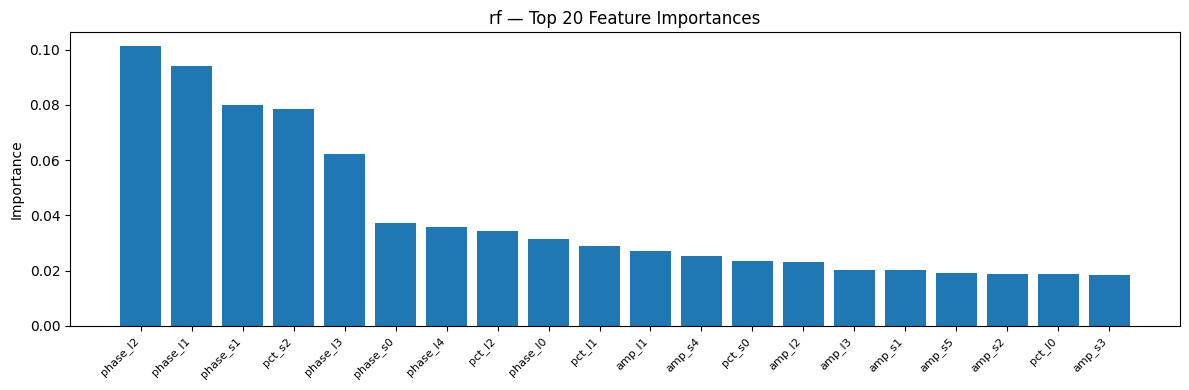

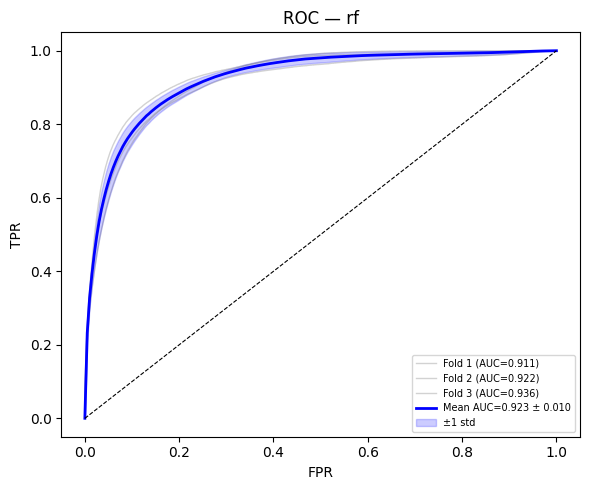

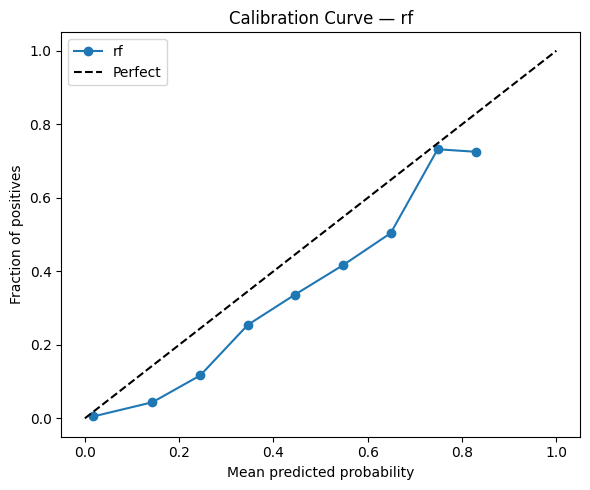


  Per-sample IoU — best fold 3 (val IoU=0.2725):
  s0/bottom_right                           IoU=0.1931
  s0/mid_left                               IoU=0.2953
  s2/bottom_right                           IoU=0.0042
  s2/mid_left                               IoU=0.2489
  s2/top_mid                                IoU=0.1381
  s4/mid_right                              IoU=0.4933
  s4/top_left                               IoU=0.2675


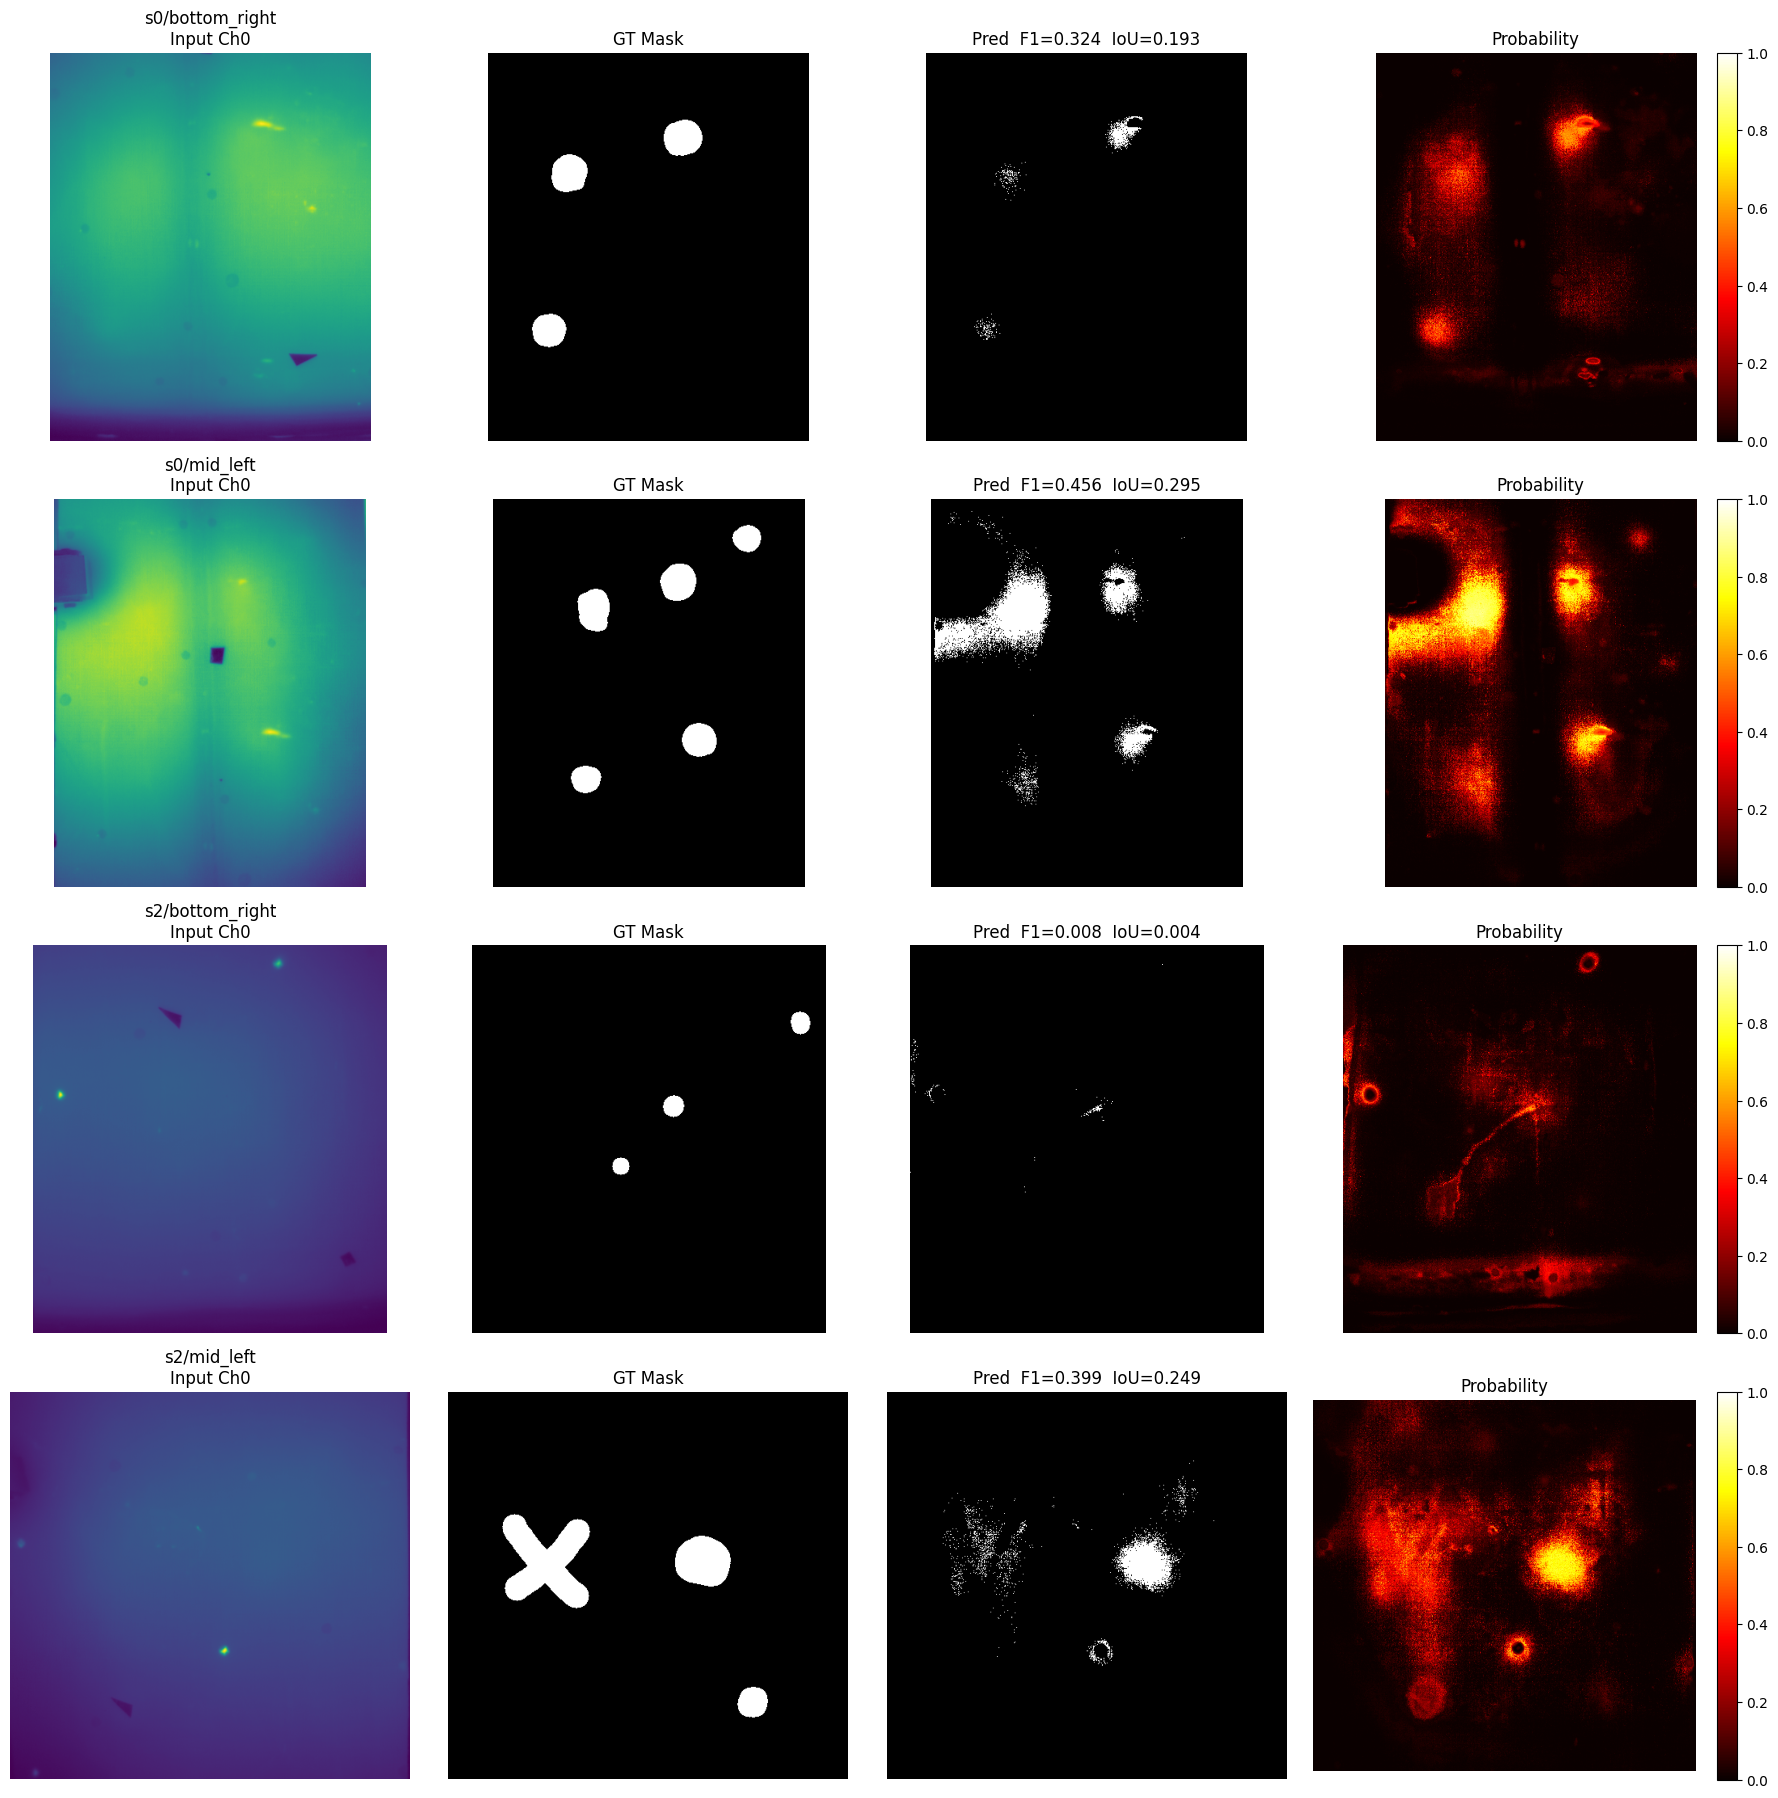


MLflow run: 4bf67f4d3a814a39911554e645128a63


In [16]:
print('=== Rf ===')
rf_model = train_model('rf', MODELS['rf'], samples_data, sample_classes, valid_samples)

In [15]:
fold_splits = _build_fold_splits(valid_samples, N_SPLITS, sample_classes)
last_tr_loc, last_va_loc = fold_splits[-1]
X_tr_last = np.concatenate([samples_data[i][0] for i in last_tr_loc])
y_tr_last = np.concatenate([samples_data[i][1] for i in last_tr_loc])
X_va_last = np.concatenate([samples_data[i][0] for i in last_va_loc])
y_va_last = np.concatenate([samples_data[i][1] for i in last_va_loc])

prob_tr_last = rf_model.predict_proba(X_tr_last)[:, 1]
prob_va_last = rf_model.predict_proba(X_va_last)[:, 1]
thresholds = np.linspace(0.05, 0.95, 91)
va_scores = [_binary_metrics_at_threshold(y_va_last, prob_va_last, t) for t in thresholds]
best = max(va_scores, key=lambda m: m['iou'])
train_at_best = _binary_metrics_at_threshold(y_tr_last, prob_tr_last, best['threshold'])

print(f"Best threshold on last validation fold: {best['threshold']:.2f}")
print(f"  train IoU={train_at_best['iou']:.4f} F1={train_at_best['f1']:.4f} "
      f"prec={train_at_best['prec']:.4f} rec={train_at_best['rec']:.4f}")
print(f"  val   IoU={best['iou']:.4f} F1={best['f1']:.4f} "
      f"prec={best['prec']:.4f} rec={best['rec']:.4f}")

plt.figure(figsize=(7, 4))
plt.plot([m['threshold'] for m in va_scores], [m['iou'] for m in va_scores], label='val IoU')
plt.plot([m['threshold'] for m in va_scores], [m['f1'] for m in va_scores], label='val F1')
plt.axvline(best['threshold'], color='k', linestyle='--', linewidth=1, label=f"best IoU @ {best['threshold']:.2f}")
plt.xlabel('Probability threshold')
plt.ylabel('Score')
plt.title('XGBoost threshold optimisation - last fold')
plt.legend()
plt.tight_layout()
plt.show()

  Loaded 3 fold splits from /home/aaverin/RZ-Dienste/hpc-user/aaverin/Python/KIprojV2_Claude/NNsTorchV2/HybridTrainV2/fold_splits/unet/20260413-095040


NameError: name 'rf_model' is not defined

In [ ]:
# ── Compare top features: XGB vs RF ──────────────────────────────────────────
top_n   = 20
xgb_imp = xgb_model.feature_importances_
rf_imp  = rf_model.feature_importances_
idx     = np.argsort(xgb_imp)[-top_n:][::-1]

x, w = np.arange(top_n), 0.35
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(x - w/2, xgb_imp[idx] / xgb_imp.max(), w, label='XGB (normalised)')
ax.bar(x + w/2, rf_imp[idx]  / rf_imp.max(),  w, label='RF (normalised)', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(idx, rotation=45)
ax.set_xlabel('Feature index')
ax.set_ylabel('Normalised importance')
ax.set_title(f'Top {top_n} Features — XGB vs RF (ranked by XGB)')
ax.legend()
fig.tight_layout()
plt.show()
print(f'Top-5 features (XGB rank): {idx[:5]}')

In [ ]:
# ── Reminder: view in MLflow UI ───────────────────────────────────────────────
print(f'View results:')
print(f'  mlflow ui --backend-store-uri {MLFLOW_URI}')
print(f'  Experiment: {MLFLOW_EXPERIMENT}')